# h1_v1_allow Outlier EDA

`data_h1_v1_allow`의 휴먼(ALLOW) trial만 대상으로 한 EDA입니다.

목적은 다음 두 가지입니다.
1. feature 자체의 품질 문제를 먼저 정리한다.
2. 모델 학습 전에 제외 검토할 outlier trial의 범위를 좁힐 수 있는 기준선을 만든다.

`eda_template`의 큰 섹션 구조를 따르되, `eda_chan`처럼 실제 판단에 도움이 되는 표와 셀 흐름 위주로 구성합니다.

In [17]:
import json
import platform
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

In [18]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 1200)

system = platform.system()
if system == "Darwin":
    font_candidates = ["Nanum Gothic", "AppleGothic"]
elif system == "Windows":
    font_candidates = ["Malgun Gothic"]
else:
    font_candidates = ["Nanum Gothic", "DejaVu Sans"]

for font_name in font_candidates:
    try:
        plt.rcParams["font.family"] = font_name
        print(f"한글 폰트 적용: {font_name}")
        break
    except Exception:
        continue

plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", context="notebook")

한글 폰트 적용: Malgun Gothic


## 1. 데이터 로드

In [19]:
ROOT = Path.cwd()
if ROOT.name != "EDA":
    raise RuntimeError("작업 디렉토리를 services/ai/train/EDA 로 맞춘 뒤 실행하세요.")

DATA_DIR = ROOT.parent.parent / "data" / "data_h1_v1_allow"
FEATURE_CONFIG_PATH = ROOT.parent.parent / "configs" / "feature_config.yaml"

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("FEATURE_CONFIG_PATH:", FEATURE_CONFIG_PATH)

if not DATA_DIR.exists():
    raise FileNotFoundError(DATA_DIR)
if not FEATURE_CONFIG_PATH.exists():
    raise FileNotFoundError(FEATURE_CONFIG_PATH)

ROOT: c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\train\EDA
DATA_DIR: c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow
FEATURE_CONFIG_PATH: c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\configs\feature_config.yaml


In [20]:
with open(FEATURE_CONFIG_PATH, "r", encoding="utf-8") as f:
    feature_config = yaml.safe_load(f)

FEATURE_GROUPS = feature_config["groups"]
FEATURE_NAME_KR = feature_config.get("names_ko", {})
EXCLUDE_COL = set(feature_config.get("exclude", [])) | {"trial_id", "label"}
FEATURE_GROUP_MAP = {
    feature: group
    for group, features in FEATURE_GROUPS.items()
    for feature in features
}


def load_allow_trials(data_dir: Path) -> pd.DataFrame:
    rows = []
    for path in sorted(data_dir.glob("trial_*.json")):
        payload = json.loads(path.read_text(encoding="utf-8"))
        trial_id = payload.get("trialID") or payload.get("trialId") or payload.get("trial_id")
        label = payload.get("label")
        feature_values = payload.get("features") or payload.get("metrics") or {}

        row = {
            "trial_id": int(trial_id),
            "label": label,
            "path": str(path),
        }
        if isinstance(feature_values, dict):
            row.update(feature_values)
        rows.append(row)

    frame = pd.DataFrame(rows).sort_values("trial_id").reset_index(drop=True)
    return frame


df = load_allow_trials(DATA_DIR)
print("trial 수:", len(df))
print("label 분포:")
print(df["label"].value_counts(dropna=False).to_string())
display(df.head())

trial 수: 719
label 분포:
label
ALLOW    719


,trial_id,label,path,reclick_rate,misclick_rate,mouse_jerk_mean,double_click_rate,mouse_overshoot_flag,mousemove_event_rate,pre_click_scroll_flag,time_to_first_click_ms,inter_click_interval_ms,mouse_acceleration_mean,mouse_speed_change_mean,pre_click_hover_time_ms,click_offset_variance_px,mouse_stop_segment_count,mouse_avg_speed_px_per_ms,mouse_hover_dwell_time_ms,mouse_max_speed_px_per_ms,mouse_path_curvature_mean,pre_click_mousemove_count,click_position_repeat_rate,mouse_direction_change_count,mouse_path_straightness_score,edge_or_fixed_point_visit_rate,mouse_total_travel_distance_px,click_sequence_consistency_score,immediate_post_render_click_rate,pre_click_path_300ms_straightness,pre_click_path_500ms_straightness,inter_element_move_interval_std_ms,click_offset_from_element_center_px,time_from_element_visible_to_click_ms,pre_click_path_300ms_total_distance_px,pre_click_path_500ms_total_distance_px,time_from_element_clickable_to_click_ms
0,1,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00001.json,0,0,0.000162,0.000000,0,9.750813,0.0,1075,1308.500000,0.009328,0.533719,306.333333,None,2.0,0.395309,None,2.734838,0.032035,3.333333,0.0,8.0,0.168428,0.000000,1459.479483,0.0,None,0.00,0.00,None,None,None,0,0,None
1,2,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00002.json,0,0,0.000080,0.333333,0,7.798960,0.0,2488,364.000000,0.005454,0.316669,108.333333,None,2.0,0.170488,None,1.216224,0.042221,6.333333,0.0,11.0,0.098543,0.000000,983.717067,0.0,None,1.00,0.82,None,None,None,58,84,None
2,3,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00003.json,0,0,0.000174,0.125000,0,8.876035,0.0,2488,1076.857143,0.009364,0.529256,145.500000,None,10.0,0.315634,None,5.275129,0.066866,5.500000,0.0,22.0,0.205605,0.022472,3164.858153,0.0,None,0.99,0.99,None,None,None,32,64,None
3,4,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00004.json,0,0,0.000318,0.500000,0,0.709133,0.0,122347,59193.500000,0.020602,1.331996,217.000000,None,17.0,0.088975,None,8.596046,0.041503,4.500000,0.0,24.0,0.040737,0.114943,10915.932756,0.0,None,1.00,1.00,None,None,None,35,35,None
4,5,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00005.json,0,0,0.000076,0.000000,0,4.015143,0.0,2461,1852.500000,0.004967,0.324423,563.000000,None,8.0,0.093782,None,1.580975,0.112352,2.666667,0.0,11.0,0.294376,0.000000,817.494750,0.0,None,0.00,0.00,None,None,None,0,0,None


## 2. 데이터 전처리

In [21]:
meta_cols = [c for c in ["trial_id", "label", "path"] if c in df.columns]
raw_feature_cols = [c for c in df.columns if c not in meta_cols and c not in EXCLUDE_COL]

numeric_df = df.copy()
for col in raw_feature_cols:
    numeric_df[col] = pd.to_numeric(numeric_df[col], errors="coerce")

all_null_cols = [c for c in raw_feature_cols if numeric_df[c].notna().sum() == 0]
mostly_null_cols = [c for c in raw_feature_cols if numeric_df[c].isna().mean() >= 0.95]
constant_cols = []
for col in raw_feature_cols:
    valid = numeric_df[col].dropna()
    if len(valid) > 0 and valid.nunique() <= 1:
        constant_cols.append(col)

analysis_feature_cols = [
    c for c in raw_feature_cols
    if c not in set(all_null_cols)
]

print("원본 feature 수:", len(raw_feature_cols))
print("전부 null feature 수:", len(all_null_cols))
print("95% 이상 null feature 수:", len(mostly_null_cols))
print("상수 feature 수:", len(constant_cols))
print("분석 대상 feature 수:", len(analysis_feature_cols))

if all_null_cols:
    print("\n[all-null feature]")
    print(all_null_cols)

if mostly_null_cols:
    print("\n[95%+ null feature]")
    print(mostly_null_cols)

if constant_cols:
    print("\n[constant feature]")
    print(constant_cols)

# ============================================================
# 2-1. trial별 numeric feature count 분석
# ============================================================

# 학습에 실제로 들어갈 27개 feature 기준으로 numeric 값 개수 계산
numeric_df["numeric_count"] = numeric_df[analysis_feature_cols].notna().sum(axis=1)

numeric_count_summary = (
    numeric_df
    .groupby("numeric_count")
    .agg(
        trial_count=("trial_id", "count"),
        trial_ids_preview=("trial_id", lambda s: list(s.head(20))),
    )
    .reset_index()
    .sort_values("numeric_count", ascending=False)
)

numeric_count_summary["ratio"] = (
    numeric_count_summary["trial_count"] / len(numeric_df)
)

display(numeric_count_summary)

print("[numeric_count 해석]")
print("- 27: 주류 정상 패턴")
print("- 24: click 통계 3개가 비는 패턴. click 1회 trial로 추정되므로 유지 후보")
print("- 23: count=24 패턴 + mouse_jerk_mean 결측. 일단 유지 후보")
print("- 13 이하: mouse/click 통계가 대량 결측된 수집 실패성 trial 후보")

원본 feature 수: 34
전부 null feature 수: 7
95% 이상 null feature 수: 7
상수 feature 수: 4
분석 대상 feature 수: 27

[all-null feature]
['click_offset_variance_px', 'mouse_hover_dwell_time_ms', 'immediate_post_render_click_rate', 'inter_element_move_interval_std_ms', 'click_offset_from_element_center_px', 'time_from_element_visible_to_click_ms', 'time_from_element_clickable_to_click_ms']

[95%+ null feature]
['click_offset_variance_px', 'mouse_hover_dwell_time_ms', 'immediate_post_render_click_rate', 'inter_element_move_interval_std_ms', 'click_offset_from_element_center_px', 'time_from_element_visible_to_click_ms', 'time_from_element_clickable_to_click_ms']

[constant feature]
['reclick_rate', 'misclick_rate', 'mouse_overshoot_flag', 'click_sequence_consistency_score']


,numeric_count,trial_count,trial_ids_preview,ratio
5,27,488,"[1, 2, 3, 4, 5, 6, 8, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 25]",0.678720
4,26,17,"[199, 211, 367, 372, 375, 378, 380, 381, 486, 489, 492, 569, 578, 582, 585, 588, 591]",0.023644
3,24,191,"[7, 9, 12, 21, 27, 30, 33, 36, 39, 42, 45, 51, 52, 55, 56, 61, 62, 66, 69, 72]",0.265647
2,23,7,"[24, 178, 465, 488, 494, 537, 540]",0.009736
1,20,2,"[210, 485]",0.002782
0,13,14,"[195, 206, 333, 366, 371, 374, 377, 491, 568, 576, 581, 584, 587, 590]",0.019471


[numeric_count 해석]
- 27: 주류 정상 패턴
- 24: click 통계 3개가 비는 패턴. click 1회 trial로 추정되므로 유지 후보
- 23: count=24 패턴 + mouse_jerk_mean 결측. 일단 유지 후보
- 13 이하: mouse/click 통계가 대량 결측된 수집 실패성 trial 후보


In [22]:
def feature_quality_summary(frame: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    rows = []
    for feature in feature_cols:
        s = pd.to_numeric(frame[feature], errors="coerce")
        valid = s.dropna()
        q01 = valid.quantile(0.01) if len(valid) else np.nan
        q05 = valid.quantile(0.05) if len(valid) else np.nan
        q25 = valid.quantile(0.25) if len(valid) else np.nan
        q50 = valid.quantile(0.50) if len(valid) else np.nan
        q75 = valid.quantile(0.75) if len(valid) else np.nan
        q95 = valid.quantile(0.95) if len(valid) else np.nan
        q99 = valid.quantile(0.99) if len(valid) else np.nan
        iqr = q75 - q25 if pd.notna(q75) and pd.notna(q25) else np.nan
        lower = q25 - 1.5 * iqr if pd.notna(iqr) else np.nan
        upper = q75 + 1.5 * iqr if pd.notna(iqr) else np.nan
        iqr_outlier_ratio = float(((valid < lower) | (valid > upper)).mean()) if len(valid) and pd.notna(lower) else np.nan
        median = valid.median() if len(valid) else np.nan
        mad = (valid - median).abs().median() if len(valid) else np.nan
        robust_scale = mad * 1.4826 if pd.notna(mad) else np.nan
        if pd.notna(robust_scale) and robust_scale > 1e-12:
            robust_z = (valid - median) / robust_scale
            robust_outlier_ratio = float((robust_z.abs() >= 3.5).mean())
        else:
            robust_outlier_ratio = np.nan
        rows.append(
            {
                "group": FEATURE_GROUP_MAP.get(feature, "other"),
                "feature": feature,
                "feature_ko": FEATURE_NAME_KR.get(feature, feature),
                "count": int(valid.shape[0]),
                "null_ratio": float(s.isna().mean()),
                "zero_ratio": float((valid == 0).mean()) if len(valid) else np.nan,
                "n_unique": int(valid.nunique()) if len(valid) else 0,
                "mean": float(valid.mean()) if len(valid) else np.nan,
                "std": float(valid.std()) if len(valid) else np.nan,
                "min": float(valid.min()) if len(valid) else np.nan,
                "q01": float(q01) if pd.notna(q01) else np.nan,
                "q05": float(q05) if pd.notna(q05) else np.nan,
                "q25": float(q25) if pd.notna(q25) else np.nan,
                "median": float(q50) if pd.notna(q50) else np.nan,
                "q75": float(q75) if pd.notna(q75) else np.nan,
                "q95": float(q95) if pd.notna(q95) else np.nan,
                "q99": float(q99) if pd.notna(q99) else np.nan,
                "max": float(valid.max()) if len(valid) else np.nan,
                "iqr": float(iqr) if pd.notna(iqr) else np.nan,
                "iqr_outlier_ratio": iqr_outlier_ratio,
                "robust_outlier_ratio": robust_outlier_ratio,
                "skew": float(valid.skew()) if len(valid) > 2 else np.nan,
            }
        )
    return pd.DataFrame(rows)


def robust_zscore(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    median = s.median()
    mad = (s - median).abs().median()
    scale = mad * 1.4826
    if pd.isna(scale) or scale <= 1e-12:
        return pd.Series(np.nan, index=s.index)
    return (s - median) / scale


def iqr_bounds(series: pd.Series) -> tuple[float, float]:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) == 0:
        return (np.nan, np.nan)
    q25 = s.quantile(0.25)
    q75 = s.quantile(0.75)
    iqr = q75 - q25
    return (q25 - 1.5 * iqr, q75 + 1.5 * iqr)


def percentile_rank(series: pd.Series, value: float) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) == 0 or pd.isna(value):
        return np.nan
    return float((s <= value).mean())


def top_feature_list(summary_df: pd.DataFrame, top_n: int = 12) -> list[str]:
    cols = summary_df.sort_values(
        ["iqr_outlier_ratio", "robust_outlier_ratio", "null_ratio"],
        ascending=[False, False, True],
    )["feature"].tolist()
    return cols[:top_n]

## 3. 기본 분석

In [23]:
feature_summary_df = feature_quality_summary(numeric_df, analysis_feature_cols)
feature_summary_df = feature_summary_df.sort_values(
    ["null_ratio", "iqr_outlier_ratio", "robust_outlier_ratio"],
    ascending=[False, False, False],
).reset_index(drop=True)

candidate_drop_df = feature_summary_df[
    (feature_summary_df["null_ratio"] >= 0.95)
    | (feature_summary_df["n_unique"] <= 1)
    | (feature_summary_df["zero_ratio"] >= 0.98)
].copy()

print("feature quality summary")
display(feature_summary_df)

print("\n모델 학습 전 제외 검토가 필요한 feature 후보")
display(candidate_drop_df[[
    "group", "feature", "null_ratio", "zero_ratio", "n_unique", "iqr_outlier_ratio", "robust_outlier_ratio"
]].sort_values(["null_ratio", "zero_ratio", "n_unique"], ascending=[False, False, True]))

feature quality summary


,group,feature,feature_ko,count,null_ratio,zero_ratio,n_unique,mean,std,min,q01,q05,q25,median,q75,q95,q99,max,iqr,iqr_outlier_ratio,robust_outlier_ratio,skew
0,click,click_position_repeat_rate,좌표 반복률,506,0.296245,0.903162,23,0.018667,6.842460e-02,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.142857,0.333333,6.666667e-01,0.000000,0.096838,NaN,4.857280
1,other,inter_click_interval_ms,inter_click_interval_ms,506,0.296245,0.000000,487,2095.267934,9.891646e+03,2.065000e+02,2.506500e+02,322.750000,526.500000,948.692857,1409.375000,3938.250000,18759.666667,2.034654e+05,882.875000,0.090909,0.071146,17.418503
2,click,click_sequence_consistency_score,순서 일관성,506,0.296245,1.000000,1,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,NaN,0.000000
3,mouse,mouse_jerk_mean,저크 평균,679,0.055633,0.000000,678,0.000155,1.035812e-04,9.821807e-08,3.255624e-07,0.000035,0.000090,0.000136,0.000194,0.000346,0.000532,9.029256e-04,0.000104,0.047128,0.032401,1.869213
4,mouse,mouse_acceleration_mean,가속도 변화,702,0.023644,0.001425,701,0.008893,5.978850e-03,0.000000e+00,1.511265e-04,0.001399,0.005192,0.007855,0.011615,0.019438,0.027979,5.036277e-02,0.006422,0.038462,0.024217,2.078454
5,mouse,mouse_speed_change_mean,속도 변화,702,0.023644,0.001425,701,0.543795,3.622612e-01,0.000000e+00,8.192285e-02,0.145315,0.313110,0.471291,0.683265,1.169013,1.900204,3.027826e+00,0.370156,0.037037,0.029915,2.311608
6,mouse,mouse_path_curvature_mean,경로 곡률,702,0.023644,0.001425,701,0.105095,6.607833e-02,0.000000e+00,3.581006e-03,0.016263,0.059378,0.099369,0.136773,0.226847,0.322464,5.639398e-01,0.077395,0.027066,0.011396,1.383457
7,mouse,edge_or_fixed_point_visit_rate,고정점 방문률,705,0.019471,0.795745,81,0.014402,5.561416e-02,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.089595,0.264696,1.000000e+00,0.000000,0.204255,NaN,10.122807
8,mouse,mouse_path_straightness_score,경로 직선성,705,0.019471,0.000000,701,0.287490,2.712233e-01,4.702870e-03,1.787626e-02,0.035186,0.110907,0.192705,0.321147,0.954359,0.998620,1.000000e+00,0.210241,0.141844,0.127660,1.484678
9,mouse,mouse_avg_speed_px_per_ms,평균 속도,705,0.019471,0.000000,704,0.255884,1.872578e-01,2.103401e-05,1.823179e-02,0.045784,0.133143,0.224564,0.335533,0.553790,0.983633,1.857964e+00,0.202390,0.034043,0.019858,2.622990



모델 학습 전 제외 검토가 필요한 feature 후보


,group,feature,null_ratio,zero_ratio,n_unique,iqr_outlier_ratio,robust_outlier_ratio
2,click,click_sequence_consistency_score,0.296245,1.000000,1,0.000000,NaN
23,click,reclick_rate,0.000000,1.000000,1,0.000000,NaN
24,click,misclick_rate,0.000000,1.000000,1,0.000000,NaN
26,mouse,mouse_overshoot_flag,0.000000,1.000000,1,0.000000,NaN
19,click,pre_click_scroll_flag,0.000000,0.998609,2,0.001391,NaN


`comment`
- 여기서는 먼저 feature 자체를 걸러냅니다.
- `null_ratio`가 매우 높거나, 거의 항상 0이거나, 사실상 상수인 feature는 trial outlier보다도 feature 설계 문제일 가능성이 큽니다.
- 이 셀 결과는 이후 `analysis_feature_cols`를 더 줄일지 판단하는 출발점으로 사용합니다.

### 3-1 데이터 분포 시각화

분포 확인 우선순위 feature:
['edge_or_fixed_point_visit_rate', 'mouse_path_straightness_score', 'time_to_first_click_ms', 'pre_click_hover_time_ms', 'click_position_repeat_rate', 'inter_click_interval_ms', 'pre_click_path_500ms_total_distance_px', 'mouse_jerk_mean', 'mouse_acceleration_mean', 'mouse_speed_change_mean', 'mouse_avg_speed_px_per_ms', 'pre_click_path_300ms_total_distance_px']


C:\Users\SSAFY\AppData\Local\Temp\ipykernel_17452\2203780475.py:19: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_17452\2203780475.py:19: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_17452\2203780475.py:19: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_17452\2203780475.py:19: UserWarning: Glyph 53664 (\N{HANGUL SYLLABLE TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_17452\2203780475.py:19: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_17452\2203780475.py:19: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) Arial.
  plt.tight_la

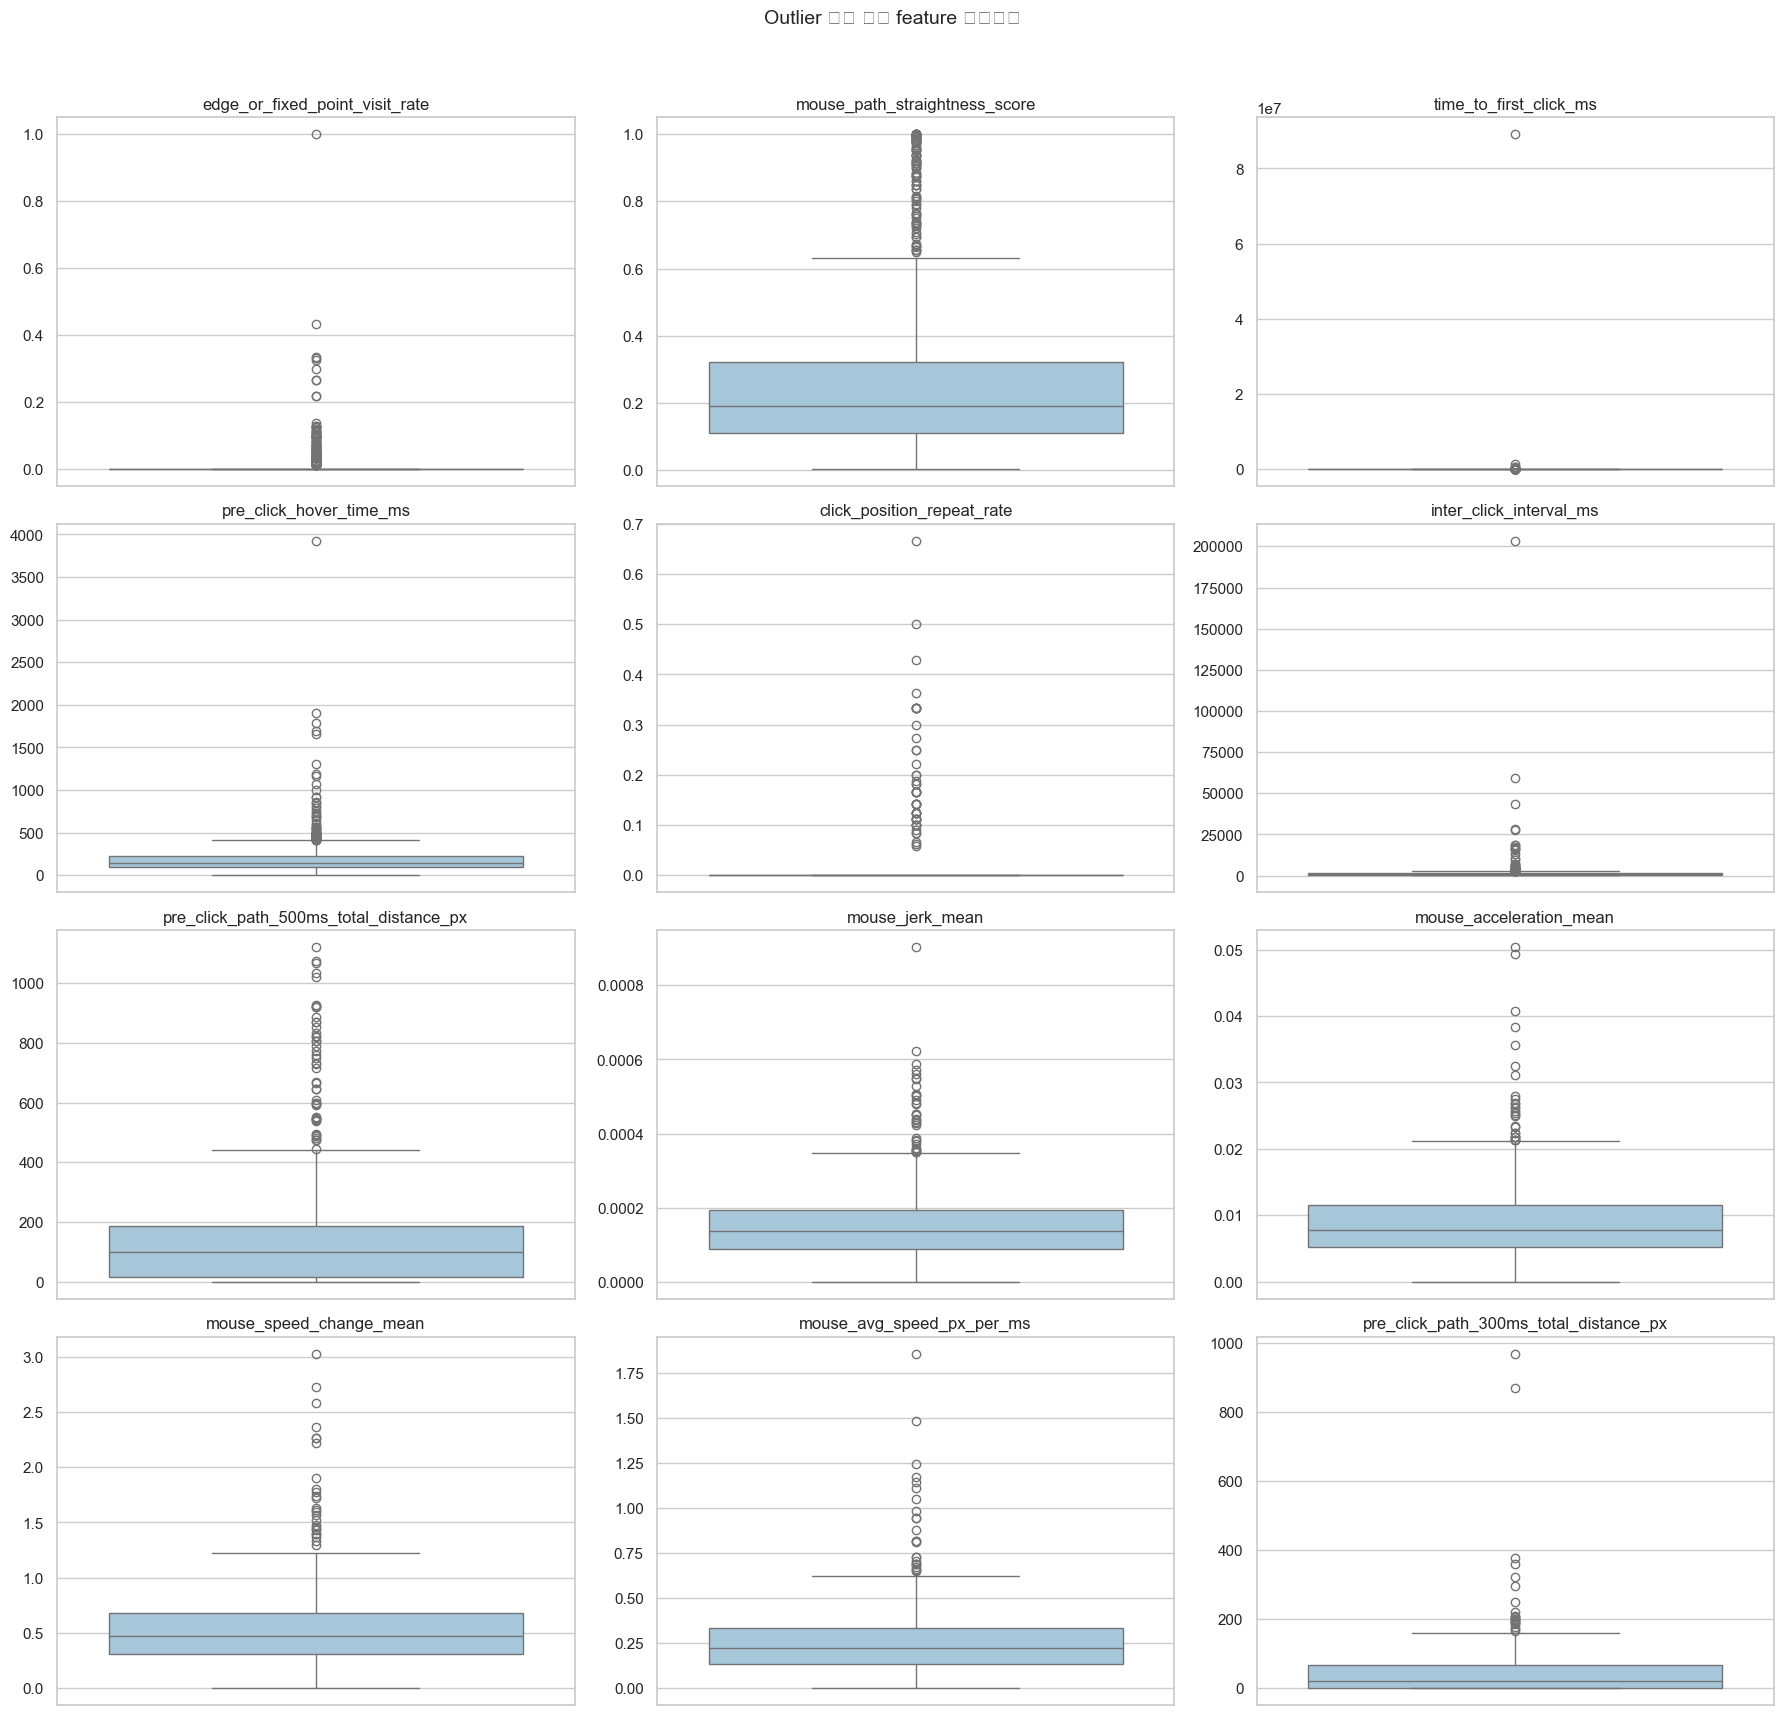

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_17452\2203780475.py:40: UserWarning: Glyph 44537 (\N{HANGUL SYLLABLE GEUG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_17452\2203780475.py:40: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_17452\2203780475.py:40: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_17452\2203780475.py:40: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_17452\2203780475.py:40: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_17452\2203780475.py:40: UserWarning: Glyph 50756 (\N{HANGUL SYLLABLE WAN}) missing from font(s) Arial.
  plt.t

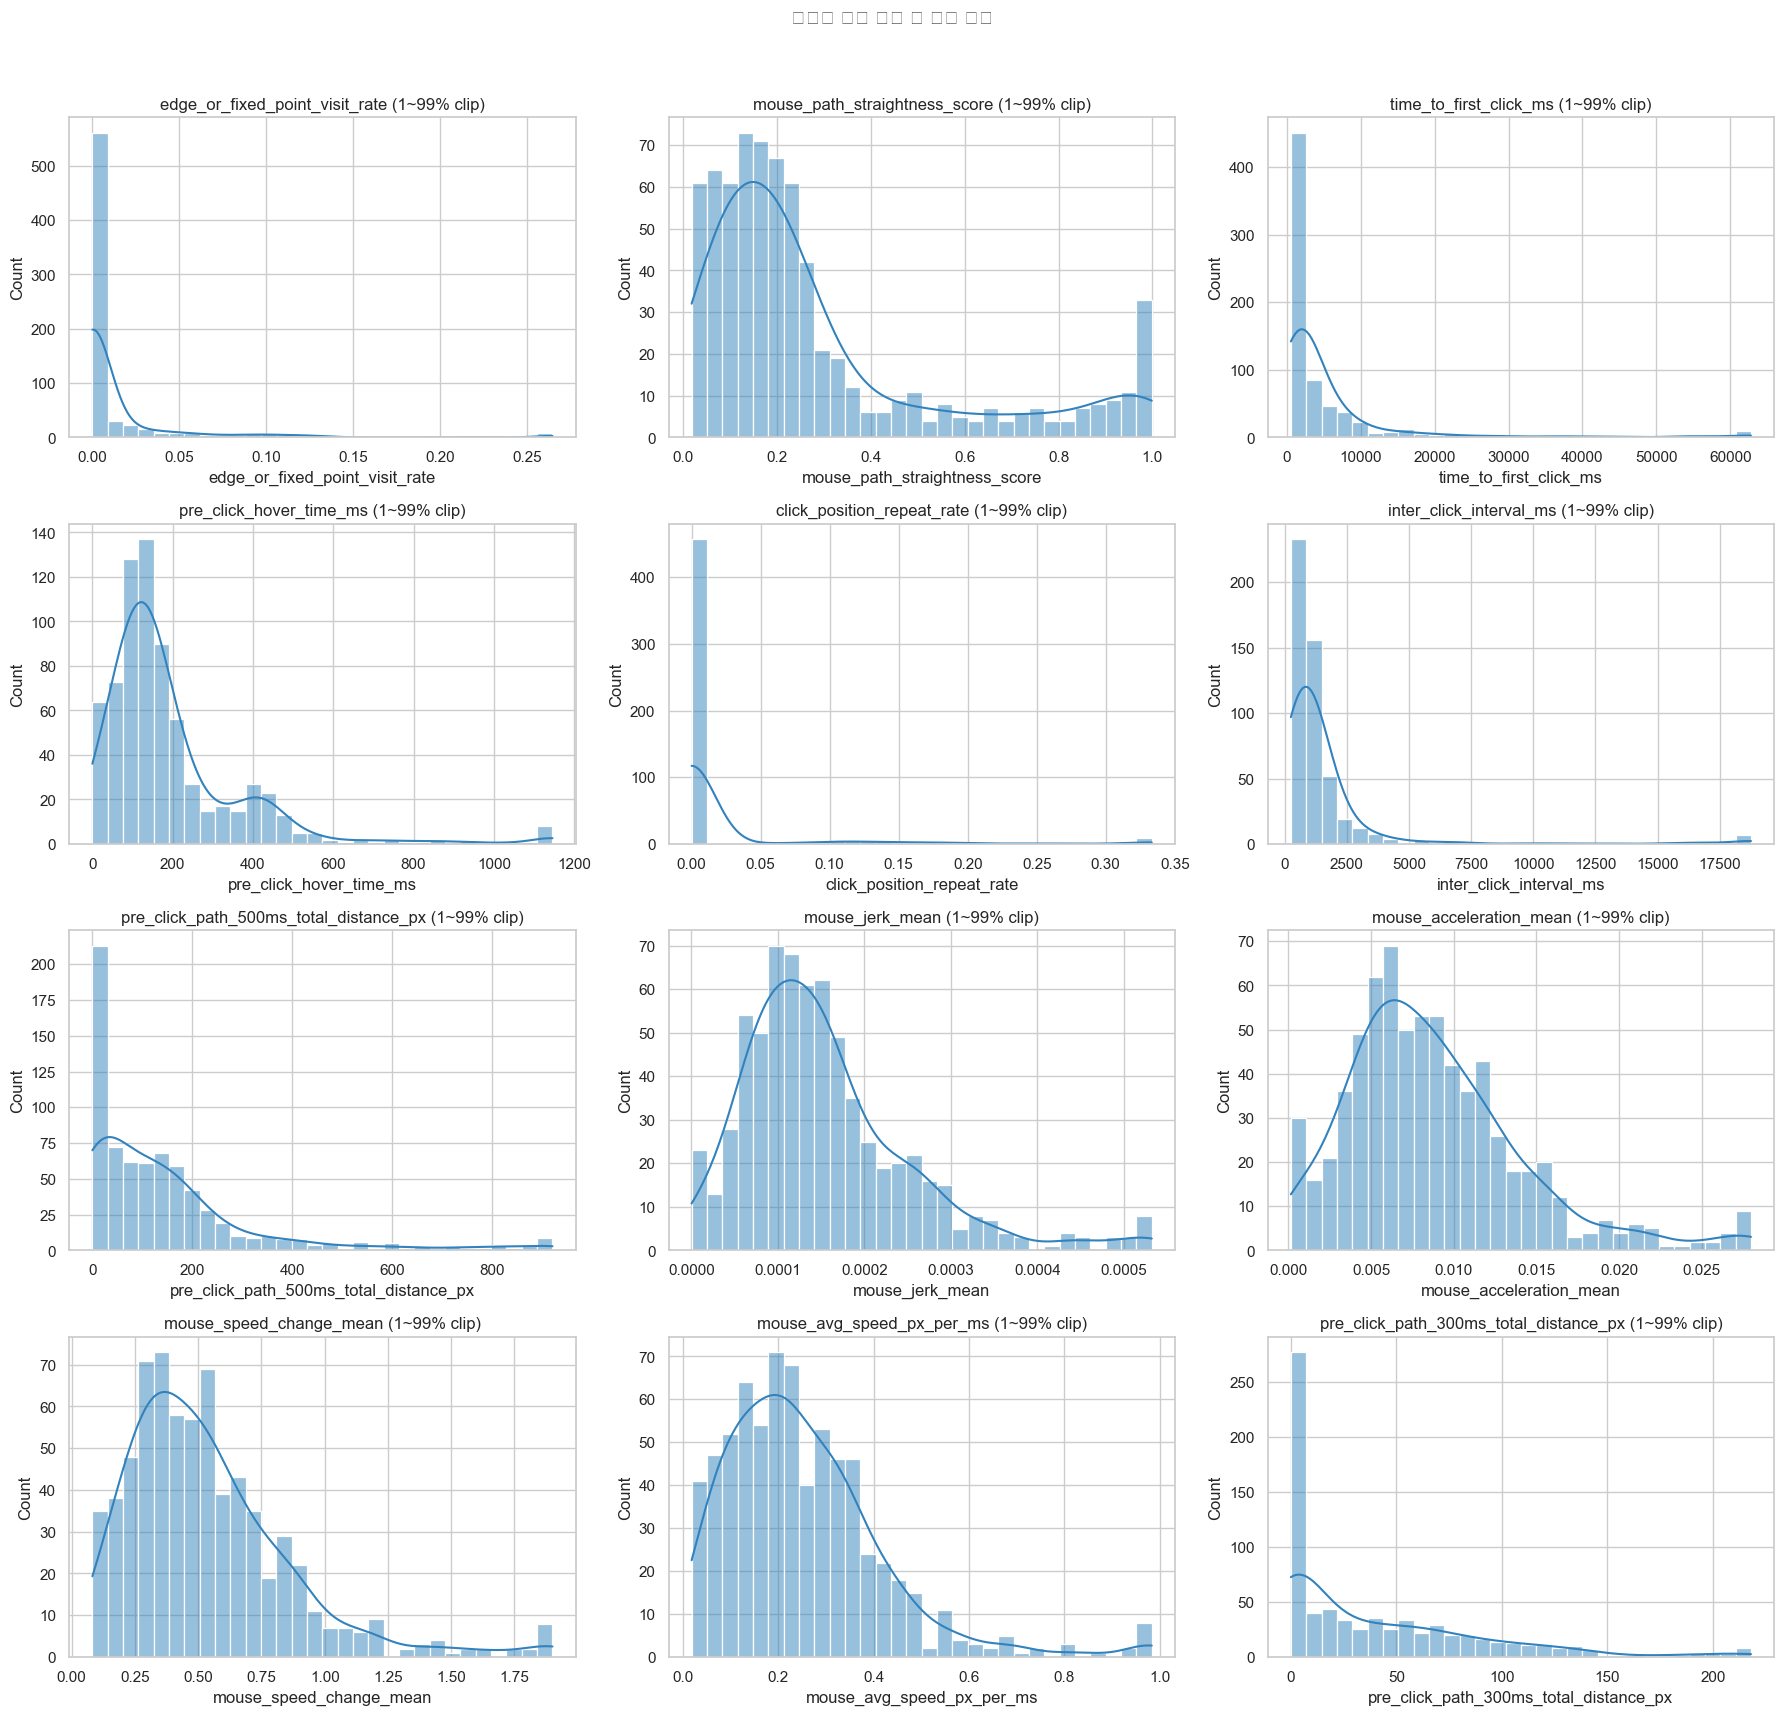

In [24]:
focus_features = top_feature_list(feature_summary_df, top_n=12)
print("분포 확인 우선순위 feature:")
print(focus_features)

ncols = 3
nrows = int(np.ceil(len(focus_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.2 * nrows))
axes = np.array(axes).reshape(-1)

for ax, feature in zip(axes, focus_features):
    sns.boxplot(y=numeric_df[feature], ax=ax, color="#9ecae1")
    ax.set_title(feature)
    ax.set_ylabel("")

for ax in axes[len(focus_features):]:
    ax.axis("off")

fig.suptitle("Outlier 우선 검토 feature 박스플롯", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.2 * nrows))
axes = np.array(axes).reshape(-1)

for ax, feature in zip(axes, focus_features):
    s = pd.to_numeric(numeric_df[feature], errors="coerce").dropna()
    if len(s) == 0:
        ax.axis("off")
        continue
    low = s.quantile(0.01)
    high = s.quantile(0.99)
    clipped = s.clip(lower=low, upper=high)
    sns.histplot(clipped, bins=30, kde=True, ax=ax, color="#3182bd")
    ax.set_title(f"{feature} (1~99% clip)")

for ax in axes[len(focus_features):]:
    ax.axis("off")

fig.suptitle("극단값 영향 완화 후 분포 확인", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 3-2 상관관계 분석

c:\Users\SSAFY\miniforge3\envs\tickle\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SSAFY\miniforge3\envs\tickle\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SSAFY\miniforge3\envs\tickle\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SSAFY\miniforge3\envs\tickle\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SSAFY\miniforge3\envs\tickle\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) Ari

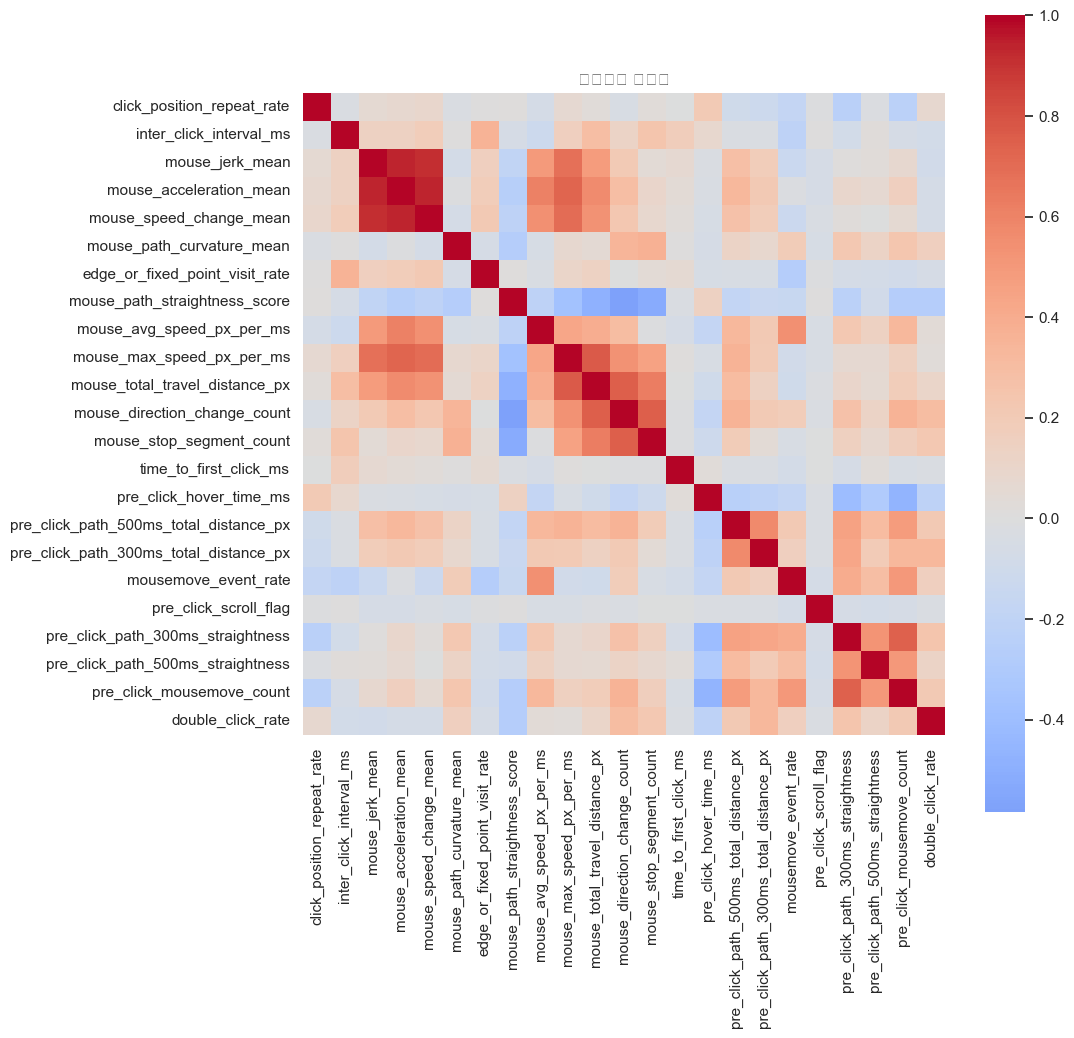

|corr| >= 0.90 pair


,feature_a,feature_b,corr
0,mouse_acceleration_mean,mouse_speed_change_mean,0.939945
1,mouse_jerk_mean,mouse_acceleration_mean,0.936767
2,mouse_jerk_mean,mouse_speed_change_mean,0.913499


In [25]:
corr_feature_cols = feature_summary_df.loc[
    (feature_summary_df["null_ratio"] < 0.50) & (feature_summary_df["n_unique"] > 1),
    "feature",
].tolist()

corr_df = numeric_df[corr_feature_cols].corr()
side = max(10, min(18, 0.45 * len(corr_feature_cols)))
plt.figure(figsize=(side, side))
sns.heatmap(corr_df, cmap="coolwarm", center=0, square=True)
plt.title("상관관계 히트맵")
plt.show()

high_corr_pairs = []
for i, left in enumerate(corr_feature_cols):
    for right in corr_feature_cols[i + 1:]:
        value = corr_df.loc[left, right]
        if pd.notna(value) and abs(value) >= 0.90:
            high_corr_pairs.append((left, right, float(value)))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["feature_a", "feature_b", "corr"])
if not high_corr_df.empty:
    high_corr_df = high_corr_df.sort_values("corr", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

print("|corr| >= 0.90 pair")
display(high_corr_df)

### 3-3 PCA

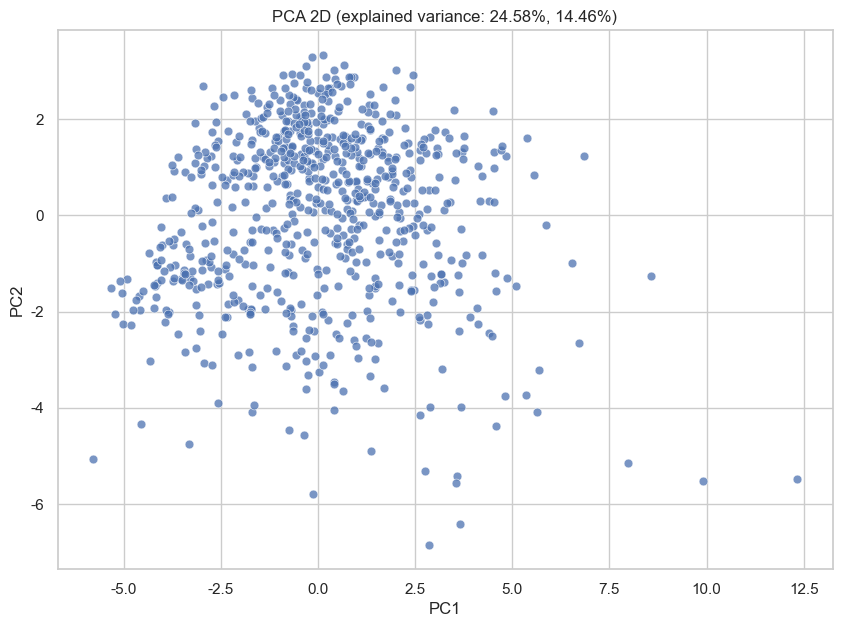

,count,mean,std,min,25%,50%,75%,max
trial_id,719.0,3.612935e+02,209.930739,1.000000,180.500000,360.000000,539.500000,750.000000
PC1,719.0,-9.882375e-17,2.379255,-5.798302,-1.650457,-0.092667,1.452346,12.334722
PC2,719.0,1.976475e-17,1.825047,-6.843034,-1.281326,0.308197,1.390162,3.335202


In [26]:
pca_feature_cols = feature_summary_df.loc[
    (feature_summary_df["null_ratio"] < 0.80) & (feature_summary_df["n_unique"] > 1),
    "feature",
].tolist()

pca_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=42)),
])

pca_coords = pca_pipe.fit_transform(numeric_df[pca_feature_cols])
pca_model = pca_pipe.named_steps["pca"]

pca_df = pd.DataFrame({
    "trial_id": numeric_df["trial_id"],
    "PC1": pca_coords[:, 0],
    "PC2": pca_coords[:, 1],
})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", s=40, alpha=0.75)
plt.title(
    f"PCA 2D (explained variance: {pca_model.explained_variance_ratio_[0]:.2%}, {pca_model.explained_variance_ratio_[1]:.2%})"
)
plt.show()

display(pca_df.describe().T)

## 4. Personal EDA

이 섹션은 **어떤 trial을 학습 전 outlier 후보로 먼저 검토할지**를 정하는 데 초점을 둡니다.

단일 기준 하나만 쓰지 않고 아래 네 축을 함께 봅니다.
- feature-wise robust z-score 이상치 개수
- IQR 기준 이상치 개수
- 1% / 99% 극단 percentile 개수
- IsolationForest raw score 기반 rank

이 네 가지를 trial-level로 합쳐서 `composite_score`를 만듭니다.

In [27]:
# trial_scores = numeric_df[["trial_id", "label", "path"]].copy()
# robust_flag_cols = []
# iqr_flag_cols = []
# extreme_flag_cols = []

# for feature in analysis_feature_cols:
#     s = pd.to_numeric(numeric_df[feature], errors="coerce")

#     rz = robust_zscore(s)
#     robust_flag = rz.abs() >= 3.5
#     robust_flag_cols.append(robust_flag.rename(feature))

#     lower, upper = iqr_bounds(s)
#     iqr_flag = (s < lower) | (s > upper)
#     iqr_flag_cols.append(iqr_flag.rename(feature))

#     valid = s.dropna()
#     if len(valid):
#         low_q = valid.quantile(0.01)
#         high_q = valid.quantile(0.99)
#         extreme_flag = (s <= low_q) | (s >= high_q)
#     else:
#         extreme_flag = pd.Series(False, index=s.index)
#     extreme_flag_cols.append(extreme_flag.rename(feature))

# robust_flag_df = pd.concat(robust_flag_cols, axis=1).fillna(False)
# iqr_flag_df = pd.concat(iqr_flag_cols, axis=1).fillna(False)
# extreme_flag_df = pd.concat(extreme_flag_cols, axis=1).fillna(False)

# trial_scores["robust_outlier_count"] = robust_flag_df.sum(axis=1)
# trial_scores["iqr_outlier_count"] = iqr_flag_df.sum(axis=1)
# trial_scores["extreme_1pct_count"] = extreme_flag_df.sum(axis=1)

# iforest_features = feature_summary_df.loc[
#     (feature_summary_df["null_ratio"] < 0.80) & (feature_summary_df["n_unique"] > 1),
#     "feature",
# ].tolist()

# iforest_pipe = Pipeline([
#     ("imputer", SimpleImputer(strategy="median")),
#     ("scaler", StandardScaler()),
#     (
#         "iforest",
#         IsolationForest(
#             n_estimators=300,
#             contamination="auto",
#             max_features=1.0,
#             random_state=42,
#         ),
#     ),
# ])
# iforest_pipe.fit(numeric_df[iforest_features])
# raw_decision = pd.Series(iforest_pipe.decision_function(numeric_df[iforest_features]), index=numeric_df.index)
# trial_scores["iforest_outlier_score"] = (-raw_decision).rank(pct=True)

# for col in ["robust_outlier_count", "iqr_outlier_count", "extreme_1pct_count"]:
#     trial_scores[f"{col}_rank"] = trial_scores[col].rank(method="average", pct=True)

# trial_scores["composite_score"] = trial_scores[[
#     "robust_outlier_count_rank",
#     "iqr_outlier_count_rank",
#     "extreme_1pct_count_rank",
#     "iforest_outlier_score",
# ]].mean(axis=1)

# trial_scores = trial_scores.sort_values(
#     ["composite_score", "iforest_outlier_score", "robust_outlier_count"],
#     ascending=[False, False, False],
# ).reset_index(drop=True)

# print("상위 outlier 의심 trial")
# display(trial_scores.head(30))

# # ============================================================
# # 4-1. outlier 후보에 numeric_count 결합
# # ============================================================

# trial_scores_with_count = trial_scores.merge(
#     numeric_df[["trial_id", "numeric_count"]],
#     on="trial_id",
#     how="left",
# )

# top_outlier_with_count = (
#     trial_scores_with_count
#     .sort_values("composite_score", ascending=False)
#     .head(30)
#     .reset_index(drop=True)
# )

# display(top_outlier_with_count[[
#     "trial_id",
#     "numeric_count",
#     "robust_outlier_count",
#     "iqr_outlier_count",
#     "extreme_1pct_count",
#     "iforest_outlier_score",
#     "composite_score",
#     "path",
# ]])

# print("[확인 포인트]")
# print("- top outlier가 numeric_count <= 13에 몰려 있으면 low-count 제거가 효과적일 가능성이 큼")
# print("- numeric_count가 24인데도 상위 outlier라면 click 1회 자체보다 다른 수치가 튄 것")
# print("- numeric_count가 27인데 상위 outlier라면 실제 행동 패턴이 특이한 trial")

# ============================================================
# 4. trial-level outlier score 계산
# ============================================================

# ------------------------------------------------------------
# outlier scoring에서 제외할 feature
# - 거의 상수이거나 정보량이 낮아서 composite_score 해석을 오염시킬 수 있는 feature
# - 단, 학습 feature에서 바로 제거한다는 뜻은 아님
# - EDA outlier 점수 계산에서만 제외
# ------------------------------------------------------------

OUTLIER_EXCLUDE_FEATURES = set(candidate_drop_df["feature"].tolist())

outlier_feature_cols = [
    feature for feature in analysis_feature_cols
    if feature not in OUTLIER_EXCLUDE_FEATURES
]

print("analysis_feature_cols:", len(analysis_feature_cols))
print("outlier_feature_cols :", len(outlier_feature_cols))
print("outlier scoring 제외 feature:")
print(sorted(OUTLIER_EXCLUDE_FEATURES))
print()

trial_scores = numeric_df[["trial_id", "label", "path"]].copy()
robust_flag_cols = []
iqr_flag_cols = []
extreme_flag_cols = []

# 기존: for feature in analysis_feature_cols:
# 수정: outlier_feature_cols 기준으로만 점수 계산
for feature in outlier_feature_cols:
    s = pd.to_numeric(numeric_df[feature], errors="coerce")

    rz = robust_zscore(s)
    robust_flag = rz.abs() >= 3.5
    robust_flag_cols.append(robust_flag.rename(feature))

    lower, upper = iqr_bounds(s)
    iqr_flag = (s < lower) | (s > upper)
    iqr_flag_cols.append(iqr_flag.rename(feature))

    valid = s.dropna()
    if len(valid):
        low_q = valid.quantile(0.01)
        high_q = valid.quantile(0.99)
        extreme_flag = (s <= low_q) | (s >= high_q)
    else:
        extreme_flag = pd.Series(False, index=s.index)

    extreme_flag_cols.append(extreme_flag.rename(feature))

robust_flag_df = pd.concat(robust_flag_cols, axis=1).fillna(False)
iqr_flag_df = pd.concat(iqr_flag_cols, axis=1).fillna(False)
extreme_flag_df = pd.concat(extreme_flag_cols, axis=1).fillna(False)

trial_scores["robust_outlier_count"] = robust_flag_df.sum(axis=1)
trial_scores["iqr_outlier_count"] = iqr_flag_df.sum(axis=1)
trial_scores["extreme_1pct_count"] = extreme_flag_df.sum(axis=1)

# ------------------------------------------------------------
# IsolationForest도 outlier_feature_cols 기준으로 계산
# ------------------------------------------------------------
iforest_features = [
    feature for feature in outlier_feature_cols
    if (
        feature_summary_df.loc[
            feature_summary_df["feature"] == feature,
            "null_ratio"
        ].iloc[0] < 0.80
        and
        feature_summary_df.loc[
            feature_summary_df["feature"] == feature,
            "n_unique"
        ].iloc[0] > 1
    )
]

print("iforest_features:", len(iforest_features))
print(iforest_features)
print()

iforest_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    (
        "iforest",
        IsolationForest(
            n_estimators=300,
            contamination="auto",
            max_features=1.0,
            random_state=42,
        ),
    ),
])

iforest_pipe.fit(numeric_df[iforest_features])

raw_decision = pd.Series(
    iforest_pipe.decision_function(numeric_df[iforest_features]),
    index=numeric_df.index,
)

trial_scores["iforest_outlier_score"] = (-raw_decision).rank(pct=True)

for col in ["robust_outlier_count", "iqr_outlier_count", "extreme_1pct_count"]:
    trial_scores[f"{col}_rank"] = trial_scores[col].rank(method="average", pct=True)

trial_scores["composite_score"] = trial_scores[[
    "robust_outlier_count_rank",
    "iqr_outlier_count_rank",
    "extreme_1pct_count_rank",
    "iforest_outlier_score",
]].mean(axis=1)

trial_scores = trial_scores.sort_values(
    ["composite_score", "iforest_outlier_score", "robust_outlier_count"],
    ascending=[False, False, False],
).reset_index(drop=True)

print("상위 outlier 의심 trial")
display(trial_scores.head(30))

# ============================================================
# 4-1. outlier 후보에 numeric_count 결합
# ============================================================

trial_scores_with_count = trial_scores.merge(
    numeric_df[["trial_id", "numeric_count"]],
    on="trial_id",
    how="left",
)

top_outlier_with_count = (
    trial_scores_with_count
    .sort_values("composite_score", ascending=False)
    .head(30)
    .reset_index(drop=True)
)

display(top_outlier_with_count[[
    "trial_id",
    "numeric_count",
    "robust_outlier_count",
    "iqr_outlier_count",
    "extreme_1pct_count",
    "iforest_outlier_score",
    "composite_score",
    "path",
]])

print("[확인 포인트]")
print("- top outlier가 numeric_count <= 13에 몰려 있으면 low-count 제거가 효과적일 가능성이 큼")
print("- numeric_count가 24인데도 상위 outlier라면 click 1회 자체보다 다른 수치가 튄 것")
print("- numeric_count가 27인데 상위 outlier라면 실제 행동 패턴이 특이한 trial")
print("- 상수/near-constant feature를 제외했으므로 이전보다 outlier 해석이 더 안정적이어야 함")

analysis_feature_cols: 27
outlier_feature_cols : 22
outlier scoring 제외 feature:
['click_sequence_consistency_score', 'misclick_rate', 'mouse_overshoot_flag', 'pre_click_scroll_flag', 'reclick_rate']

iforest_features: 22
['mouse_jerk_mean', 'double_click_rate', 'mousemove_event_rate', 'time_to_first_click_ms', 'inter_click_interval_ms', 'mouse_acceleration_mean', 'mouse_speed_change_mean', 'pre_click_hover_time_ms', 'mouse_stop_segment_count', 'mouse_avg_speed_px_per_ms', 'mouse_max_speed_px_per_ms', 'mouse_path_curvature_mean', 'pre_click_mousemove_count', 'click_position_repeat_rate', 'mouse_direction_change_count', 'mouse_path_straightness_score', 'edge_or_fixed_point_visit_rate', 'mouse_total_travel_distance_px', 'pre_click_path_300ms_straightness', 'pre_click_path_500ms_straightness', 'pre_click_path_300ms_total_distance_px', 'pre_click_path_500ms_total_distance_px']

상위 outlier 의심 trial


,trial_id,label,path,robust_outlier_count,iqr_outlier_count,extreme_1pct_count,iforest_outlier_score,robust_outlier_count_rank,iqr_outlier_count_rank,extreme_1pct_count_rank,composite_score
0,398,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00398.json,10,11,9,1.000000,1.000000,1.000000,0.985396,0.996349
1,163,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00163.json,7,8,9,0.994437,0.996523,0.997218,0.985396,0.993394
2,51,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00051.json,6,6,10,0.995828,0.992350,0.990960,0.993741,0.993220
3,325,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00325.json,6,4,8,0.973574,0.992350,0.957580,0.967316,0.972705
4,750,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00750.json,3,5,11,0.997218,0.876217,0.979138,0.998609,0.962796
5,399,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00399.json,5,4,7,0.990264,0.982615,0.957580,0.913769,0.961057
6,266,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00266.json,5,3,8,0.966620,0.982615,0.921419,0.967316,0.959492
7,729,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00729.json,5,5,7,0.961057,0.982615,0.979138,0.913769,0.959145
8,505,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00505.json,4,4,7,0.987483,0.946453,0.957580,0.913769,0.951321
9,231,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00231.json,5,3,8,0.930459,0.982615,0.921419,0.967316,0.950452


,trial_id,numeric_count,robust_outlier_count,iqr_outlier_count,extreme_1pct_count,iforest_outlier_score,composite_score,path
0,398,24,10,11,9,1.000000,0.996349,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00398.json
1,163,27,7,8,9,0.994437,0.993394,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00163.json
2,51,24,6,6,10,0.995828,0.993220,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00051.json
3,325,24,6,4,8,0.973574,0.972705,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00325.json
4,750,27,3,5,11,0.997218,0.962796,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00750.json
5,399,27,5,4,7,0.990264,0.961057,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00399.json
6,266,24,5,3,8,0.966620,0.959492,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00266.json
7,729,27,5,5,7,0.961057,0.959145,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00729.json
8,505,24,4,4,7,0.987483,0.951321,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00505.json
9,231,24,5,3,8,0.930459,0.950452,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00231.json


[확인 포인트]
- top outlier가 numeric_count <= 13에 몰려 있으면 low-count 제거가 효과적일 가능성이 큼
- numeric_count가 24인데도 상위 outlier라면 click 1회 자체보다 다른 수치가 튄 것
- numeric_count가 27인데 상위 outlier라면 실제 행동 패턴이 특이한 trial
- 상수/near-constant feature를 제외했으므로 이전보다 outlier 해석이 더 안정적이어야 함


In [28]:
candidate_rates = [0.01, 0.02, 0.03, 0.05, 0.075, 0.10]
rows = []
for rate in candidate_rates:
    threshold = trial_scores["composite_score"].quantile(1.0 - rate)
    selected = trial_scores[trial_scores["composite_score"] >= threshold]
    rows.append(
        {
            "rate": rate,
            "threshold": float(threshold),
            "flagged_trials": int(len(selected)),
            "trial_ids_preview": selected["trial_id"].head(10).tolist(),
        }
    )

contamination_sweep_df = pd.DataFrame(rows)
display(contamination_sweep_df)

# ============================================================
# 4-2. review line별 numeric_count 분포 확인
# ============================================================

review_rates = [0.01, 0.02, 0.03, 0.05]

rows = []

for rate in review_rates:
    threshold = trial_scores_with_count["composite_score"].quantile(1.0 - rate)
    selected = trial_scores_with_count[
        trial_scores_with_count["composite_score"] >= threshold
    ].copy()

    count_dist = (
        selected["numeric_count"]
        .value_counts()
        .sort_index(ascending=False)
        .to_dict()
    )

    rows.append({
        "rate": rate,
        "threshold": float(threshold),
        "flagged_trials": len(selected),
        "numeric_count_dist": count_dist,
        "trial_ids": selected.sort_values("composite_score", ascending=False)["trial_id"].tolist(),
    })

review_count_df = pd.DataFrame(rows)
display(review_count_df)

,rate,threshold,flagged_trials,trial_ids_preview
0,0.010,0.957736,8,"[398, 163, 51, 325, 750, 399, 266, 729]"
1,0.020,0.926433,15,"[398, 163, 51, 325, 750, 399, 266, 729, 505, 231]"
2,0.030,0.916603,22,"[398, 163, 51, 325, 750, 399, 266, 729, 505, 231]"
3,0.050,0.893063,36,"[398, 163, 51, 325, 750, 399, 266, 729, 505, 231]"
4,0.075,0.860327,54,"[398, 163, 51, 325, 750, 399, 266, 729, 505, 231]"
5,0.100,0.829833,72,"[398, 163, 51, 325, 750, 399, 266, 729, 505, 231]"


,rate,threshold,flagged_trials,numeric_count_dist,trial_ids
0,0.01,0.957736,8,"{27: 4, 24: 4}","[398, 163, 51, 325, 750, 399, 266, 729]"
1,0.02,0.926433,15,"{27: 7, 24: 7, 20: 1}","[398, 163, 51, 325, 750, 399, 266, 729, 505, 231, 597, 383, 330, 613, 485]"
2,0.03,0.916603,22,"{27: 9, 24: 11, 23: 1, 20: 1}","[398, 163, 51, 325, 750, 399, 266, 729, 505, 231, 597, 383, 330, 613, 485, 339, 99, 66, 543, 494, 471, 298]"
3,0.05,0.893063,36,"{27: 17, 24: 15, 23: 3, 20: 1}","[398, 163, 51, 325, 750, 399, 266, 729, 505, 231, 597, 383, 330, 613, 485, 339, 99, 66, 543, 494, 471, 298, 4, 24, 262, 320, 84, 549, 117, 327, 36, 18, 474, 534, 488, 324]"


In [29]:
def explain_trial(trial_id: int, top_n: int = 10) -> pd.DataFrame:
    row = numeric_df.loc[numeric_df["trial_id"] == trial_id]
    if row.empty:
        raise ValueError(f"trial_id {trial_id} not found")
    row = row.iloc[0]

    explain_rows = []
    for feature in analysis_feature_cols:
        series = pd.to_numeric(numeric_df[feature], errors="coerce")
        value = pd.to_numeric(pd.Series([row[feature]]), errors="coerce").iloc[0]
        if pd.isna(value):
            continue

        rz = robust_zscore(series).loc[row.name]
        lower, upper = iqr_bounds(series)
        pct = percentile_rank(series, value)

        tags = []
        if pd.notna(rz) and abs(rz) >= 3.5:
            tags.append("robust_z")
        if pd.notna(lower) and (value < lower or value > upper):
            tags.append("iqr")
        if pd.notna(pct) and (pct <= 0.01 or pct >= 0.99):
            tags.append("p01/p99")
        elif pd.notna(pct) and (pct <= 0.05 or pct >= 0.95):
            tags.append("p05/p95")

        if not tags:
            continue

        explain_rows.append(
            {
                "feature": feature,
                "feature_ko": FEATURE_NAME_KR.get(feature, feature),
                "value": value,
                "robust_z": float(rz) if pd.notna(rz) else np.nan,
                "percentile": pct,
                "iqr_lower": lower,
                "iqr_upper": upper,
                "tags": ", ".join(tags),
                "extremeness": max(abs((pct or 0) - 0.5), abs(rz) / 10 if pd.notna(rz) else 0),
            }
        )

    explain_df = pd.DataFrame(explain_rows)
    if explain_df.empty:
        return explain_df
    return explain_df.sort_values(["extremeness", "percentile"], ascending=[False, True]).head(top_n)

for _, suspicious in trial_scores.head(10).iterrows():
    trial_id = int(suspicious["trial_id"])
    print(f"\n=== trial_id {trial_id} | composite={suspicious['composite_score']:.4f} | iforest_rank={suspicious['iforest_outlier_score']:.4f} ===")
    display(explain_trial(trial_id, top_n=12))


# ============================================================
# 4-3. 시간 기반 이상 trial 후보
# ============================================================

time_check_cols = [
    "time_to_first_click_ms",
    "inter_click_interval_ms",
    "pre_click_hover_time_ms",
]

available_time_cols = [
    col for col in time_check_cols
    if col in numeric_df.columns
]

time_outlier_rows = numeric_df[["trial_id", "numeric_count", "path"] + available_time_cols].copy()

# 기준은 처음부터 너무 공격적으로 잡지 않음
# time_to_first_click_ms > 60초는 수집 중 멈춤/대기 가능성 후보
# inter_click_interval_ms > 60초도 수집 이상 가능성 후보
conditions = []

if "time_to_first_click_ms" in time_outlier_rows.columns:
    conditions.append(time_outlier_rows["time_to_first_click_ms"] > 60_000)

if "inter_click_interval_ms" in time_outlier_rows.columns:
    conditions.append(time_outlier_rows["inter_click_interval_ms"] > 60_000)

if "pre_click_hover_time_ms" in time_outlier_rows.columns:
    conditions.append(time_outlier_rows["pre_click_hover_time_ms"] > 5_000)

if conditions:
    time_mask = conditions[0]
    for cond in conditions[1:]:
        time_mask = time_mask | cond

    time_outlier_candidates = time_outlier_rows[time_mask].copy()
else:
    time_outlier_candidates = pd.DataFrame()

display(
    time_outlier_candidates
    .sort_values(
        [col for col in ["time_to_first_click_ms", "inter_click_interval_ms", "pre_click_hover_time_ms"] if col in time_outlier_candidates.columns],
        ascending=False,
    )
)

print("시간 기반 이상 후보 수:", len(time_outlier_candidates))
print("trial_id:", time_outlier_candidates["trial_id"].tolist() if len(time_outlier_candidates) else [])


=== trial_id 398 | composite=0.9963 | iforest_rank=1.0000 ===


,feature,feature_ko,value,robust_z,percentile,iqr_lower,iqr_upper,tags,extremeness
6,mouse_acceleration_mean,가속도 변화,0.049334,9.248673,0.998575,-0.004441,0.021248,"robust_z, iqr, p01/p99",0.924867
5,time_to_first_click_ms,첫 클릭 시간,11795.000000,8.377209,0.898470,-3900.250000,10429.750000,"robust_z, iqr",0.837721
7,mouse_speed_change_mean,속도 변화,2.723114,8.249683,0.998575,-0.242124,1.238499,"robust_z, iqr, p01/p99",0.824968
13,mouse_total_travel_distance_px,총 이동 거리,14682.674152,7.747419,1.000000,-3038.061994,6883.337824,"robust_z, iqr, p01/p99",0.774742
8,mouse_avg_speed_px_per_ms,평균 속도,1.244716,7.005352,0.997163,-0.170443,0.639119,"robust_z, iqr, p01/p99",0.700535
15,pre_click_path_300ms_total_distance_px,300ms 경로 총거리,194.000000,5.556519,0.980529,-99.000000,165.000000,"robust_z, iqr, p05/p95",0.555652
2,mouse_jerk_mean,저크 평균,0.000550,5.502649,0.992636,-0.000067,0.000350,"robust_z, iqr, p01/p99",0.550265
0,reclick_rate,재클릭 비율,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
1,misclick_rate,오클릭 비율,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
3,mouse_overshoot_flag,오버슈트 여부,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000



=== trial_id 163 | composite=0.9934 | iforest_rank=0.9944 ===


,feature,feature_ko,value,robust_z,percentile,iqr_lower,iqr_upper,tags,extremeness
8,mouse_avg_speed_px_per_ms,평균 속도,1.482578,8.638736,0.998582,-0.170443,0.639119,"robust_z, iqr, p01/p99",0.863874
5,inter_click_interval_ms,inter_click_interval_ms,6337.000000,8.340980,0.966403,-797.812500,2733.687500,"robust_z, iqr, p05/p95",0.834098
6,mouse_acceleration_mean,가속도 변화,0.038398,6.810286,0.995726,-0.004441,0.021248,"robust_z, iqr, p01/p99",0.681029
7,mouse_speed_change_mean,속도 변화,2.264279,6.568716,0.992877,-0.242124,1.238499,"robust_z, iqr, p01/p99",0.656872
11,mouse_total_travel_distance_px,총 이동 거리,11409.916697,5.821336,0.998582,-3038.061994,6883.337824,"robust_z, iqr, p01/p99",0.582134
2,mouse_jerk_mean,저크 평균,0.000572,5.788890,0.995582,-0.000067,0.000350,"robust_z, iqr, p01/p99",0.578889
9,mouse_max_speed_px_per_ms,최대 속도,17.766497,5.576062,1.000000,-4.758603,12.105809,"robust_z, iqr, p01/p99",0.557606
0,reclick_rate,재클릭 비율,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
1,misclick_rate,오클릭 비율,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
3,mouse_overshoot_flag,오버슈트 여부,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000



=== trial_id 51 | composite=0.9932 | iforest_rank=0.9958 ===


...

,feature,feature_ko,value,robust_z,percentile,iqr_lower,iqr_upper,tags,extremeness
9,pre_click_path_300ms_straightness,300ms 경로 직선성,0.000000,-33.050047,0.328234,-1.500000,2.500000,robust_z,3.305005
7,mouse_avg_speed_px_per_ms,평균 속도,1.142907,6.306233,0.994326,-0.170443,0.639119,"robust_z, iqr, p01/p99",0.630623
5,mouse_acceleration_mean,가속도 변화,0.031086,5.179968,0.991453,-0.004441,0.021248,"robust_z, iqr, p01/p99",0.517997
0,reclick_rate,재클릭 비율,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
1,misclick_rate,오클릭 비율,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
3,mouse_overshoot_flag,오버슈트 여부,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
10,pre_click_path_500ms_straightness,500ms 경로 직선성,1.000000,0.674491,1.000000,-0.035000,1.605000,p01/p99,0.500000
4,pre_click_scroll_flag,클릭 전 스크롤,0.000000,NaN,0.998609,0.000000,0.000000,p01/p99,0.498609
6,mouse_speed_change_mean,속도 변화,1.631504,4.250507,0.982906,-0.242124,1.238499,"robust_z, iqr, p05/p95",0.482906
8,edge_or_fixed_point_visit_rate,고정점 방문률,0.100000,NaN,0.964539,0.000000,0.000000,"iqr, p05/p95",0.464539



=== trial_id 231 | composite=0.9505 | iforest_rank=0.9305 ===


,feature,feature_ko,value,robust_z,percentile,iqr_lower,iqr_upper,tags,extremeness
8,pre_click_path_300ms_straightness,300ms 경로 직선성,0.00000,-33.050047,0.328234,-1.500000,2.500000,robust_z,3.305005
9,pre_click_path_500ms_straightness,500ms 경로 직선성,0.00000,-12.815324,0.179416,-0.035000,1.605000,robust_z,1.281532
5,mouse_path_curvature_mean,경로 곡률,0.56394,7.950426,1.000000,-0.056714,0.252865,"robust_z, iqr, p01/p99",0.795043
4,pre_click_hover_time_ms,클릭 전 hover,646.00000,5.877408,0.970793,-101.475641,417.365385,"robust_z, iqr, p05/p95",0.587741
0,reclick_rate,재클릭 비율,0.00000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
1,misclick_rate,오클릭 비율,0.00000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
2,mouse_overshoot_flag,오버슈트 여부,0.00000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
3,pre_click_scroll_flag,클릭 전 스크롤,0.00000,NaN,0.998609,0.000000,0.000000,p01/p99,0.498609
7,mouse_path_straightness_score,경로 직선성,0.90560,4.929121,0.926241,-0.204454,0.636508,"robust_z, iqr",0.492912
6,pre_click_mousemove_count,클릭 전 이동 수,0.00000,-2.271969,0.030598,-2.400000,12.000000,p05/p95,0.469402


,trial_id,numeric_count,path,time_to_first_click_ms,inter_click_interval_ms,pre_click_hover_time_ms
689,721,24,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00721.json,89146790,NaN,397.000000
382,383,27,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00383.json,1192155,17310.000000,93.571429
368,369,27,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00369.json,370785,427.500000,87.333333
338,339,27,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00339.json,338492,16657.000000,164.000000
279,280,27,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00280.json,140945,28110.333333,80.000000
3,4,27,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00004.json,122347,59193.500000,217.000000
718,750,27,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00750.json,65567,203465.428571,384.142857
717,749,27,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00749.json,63076,1245.500000,314.666667
473,474,27,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00474.json,61481,43518.000000,152.000000


시간 기반 이상 후보 수: 9
trial_id: [4, 280, 339, 369, 383, 474, 721, 749, 750]


## 5. 분석 리포트

In [30]:
drop_candidates = candidate_drop_df["feature"].tolist()
review_top_1pct = contamination_sweep_df.loc[contamination_sweep_df["rate"] == 0.01, "flagged_trials"].iloc[0]
review_top_3pct = contamination_sweep_df.loc[contamination_sweep_df["rate"] == 0.03, "flagged_trials"].iloc[0]
review_top_5pct = contamination_sweep_df.loc[contamination_sweep_df["rate"] == 0.05, "flagged_trials"].iloc[0]

print("[요약]")
print(f"- 전체 trial 수: {len(df)}")
print(f"- 분석 대상 feature 수: {len(analysis_feature_cols)}")
print(f"- 즉시 제외 검토 feature 수: {len(drop_candidates)}")
print(f"- 1% review line: 상위 {review_top_1pct}개 trial")
print(f"- 3% review line: 상위 {review_top_3pct}개 trial")
print(f"- 5% review line: 상위 {review_top_5pct}개 trial")

print("\n[권장 해석 순서]")
print("1. all-null / 95%+ null / 상수 feature를 먼저 학습 풀에서 제거 검토")
print("2. composite_score 상위 1% trial부터 수동 검토")
print("3. 너무 공격적이면 1~3% 구간만 제거, 더 보수적으로 넓히려면 3~5% 구간까지 검토")
print("4. 제거 전후로 feature별 분포와 상관관계가 얼마나 안정화되는지 재확인")

print("\n[즉시 제외 검토 feature 목록]")
print(drop_candidates)

print("\n[가장 먼저 볼 outlier 의심 trial_id]")
print(trial_scores.head(20)["trial_id"].tolist())


# ============================================================
# 5. 분석 리포트
# ============================================================

drop_candidates = candidate_drop_df["feature"].tolist()

review_top_1pct = contamination_sweep_df.loc[
    contamination_sweep_df["rate"] == 0.01,
    "flagged_trials"
].iloc[0]

review_top_3pct = contamination_sweep_df.loc[
    contamination_sweep_df["rate"] == 0.03,
    "flagged_trials"
].iloc[0]

review_top_5pct = contamination_sweep_df.loc[
    contamination_sweep_df["rate"] == 0.05,
    "flagged_trials"
].iloc[0]

print("[요약]")
print(f"- 전체 trial 수: {len(df)}")
print(f"- 분석 대상 feature 수: {len(analysis_feature_cols)}")
print(f"- 즉시 제외 검토 feature 수: {len(drop_candidates)}")
print(f"- 1% review line: 상위 {review_top_1pct}개 trial")
print(f"- 3% review line: 상위 {review_top_3pct}개 trial")
print(f"- 5% review line: 상위 {review_top_5pct}개 trial")

print("\n[feature 판단]")
print("- all-null 7개 feature는 학습에서 자동 제외되는 것이 맞음")
print("- constant/near-constant feature는 바로 삭제하지 말고 학습 버전 비교 대상으로 둠")
print("- 우선순위는 feature drop보다 bad trial 정리")

print("\n[현재 즉시 제외 검토 feature 목록]")
print(drop_candidates)

print("\n[trial 판단]")
print("- count=24 trial은 click 1회로 인한 자연 결측 가능성이 높으므로 유지")
print("- count=23 trial도 일단 유지 후보")
print("- count<=13 trial은 제거 후보")
print("- composite_score 상위 1%는 수동 검토 후보")

print("\n[가장 먼저 볼 outlier 의심 trial_id]")
top20_ids = (
    trial_scores
    .sort_values("composite_score", ascending=False)
    .head(20)["trial_id"]
    .tolist()
)
print(top20_ids)

if "numeric_count" in numeric_df.columns:
    print("\n[numeric_count 분포]")
    display(numeric_count_summary)

if "trial_scores_with_count" in globals():
    print("\n[상위 outlier + numeric_count]")
    display(
        trial_scores_with_count
        .sort_values("composite_score", ascending=False)
        .head(20)[[
            "trial_id",
            "numeric_count",
            "robust_outlier_count",
            "iqr_outlier_count",
            "extreme_1pct_count",
            "iforest_outlier_score",
            "composite_score",
        ]]
    )

if "time_outlier_candidates" in globals():
    print("\n[시간 기반 이상 후보]")
    display(time_outlier_candidates)

[요약]
- 전체 trial 수: 719
- 분석 대상 feature 수: 27
- 즉시 제외 검토 feature 수: 5
- 1% review line: 상위 8개 trial
- 3% review line: 상위 22개 trial
- 5% review line: 상위 36개 trial

[권장 해석 순서]
1. all-null / 95%+ null / 상수 feature를 먼저 학습 풀에서 제거 검토
2. composite_score 상위 1% trial부터 수동 검토
3. 너무 공격적이면 1~3% 구간만 제거, 더 보수적으로 넓히려면 3~5% 구간까지 검토
4. 제거 전후로 feature별 분포와 상관관계가 얼마나 안정화되는지 재확인

[즉시 제외 검토 feature 목록]
['click_sequence_consistency_score', 'pre_click_scroll_flag', 'reclick_rate', 'misclick_rate', 'mouse_overshoot_flag']

[가장 먼저 볼 outlier 의심 trial_id]
[398, 163, 51, 325, 750, 399, 266, 729, 505, 231, 597, 383, 330, 613, 485, 339, 99, 66, 543, 494]
[요약]
- 전체 trial 수: 719
- 분석 대상 feature 수: 27
- 즉시 제외 검토 feature 수: 5
- 1% review line: 상위 8개 trial
- 3% review line: 상위 22개 trial
- 5% review line: 상위 36개 trial

[feature 판단]
- all-null 7개 feature는 학습에서 자동 제외되는 것이 맞음
- constant/near-constant feature는 바로 삭제하지 말고 학습 버전 비교 대상으로 둠
- 우선순위는 feature drop보다 bad trial 정리

[현재 즉시 제외 검토 feature 목록]
['click_sequence_consistency

,numeric_count,trial_count,trial_ids_preview,ratio
5,27,488,"[1, 2, 3, 4, 5, 6, 8, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 25]",0.678720
4,26,17,"[199, 211, 367, 372, 375, 378, 380, 381, 486, 489, 492, 569, 578, 582, 585, 588, 591]",0.023644
3,24,191,"[7, 9, 12, 21, 27, 30, 33, 36, 39, 42, 45, 51, 52, 55, 56, 61, 62, 66, 69, 72]",0.265647
2,23,7,"[24, 178, 465, 488, 494, 537, 540]",0.009736
1,20,2,"[210, 485]",0.002782
0,13,14,"[195, 206, 333, 366, 371, 374, 377, 491, 568, 576, 581, 584, 587, 590]",0.019471



[상위 outlier + numeric_count]


,trial_id,numeric_count,robust_outlier_count,iqr_outlier_count,extreme_1pct_count,iforest_outlier_score,composite_score
0,398,24,10,11,9,1.000000,0.996349
1,163,27,7,8,9,0.994437,0.993394
2,51,24,6,6,10,0.995828,0.993220
3,325,24,6,4,8,0.973574,0.972705
4,750,27,3,5,11,0.997218,0.962796
5,399,27,5,4,7,0.990264,0.961057
6,266,24,5,3,8,0.966620,0.959492
7,729,27,5,5,7,0.961057,0.959145
8,505,24,4,4,7,0.987483,0.951321
9,231,24,5,3,8,0.930459,0.950452



[시간 기반 이상 후보]


,trial_id,numeric_count,path,time_to_first_click_ms,inter_click_interval_ms,pre_click_hover_time_ms
3,4,27,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00004.json,122347,59193.500000,217.000000
279,280,27,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00280.json,140945,28110.333333,80.000000
338,339,27,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00339.json,338492,16657.000000,164.000000
368,369,27,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00369.json,370785,427.500000,87.333333
382,383,27,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00383.json,1192155,17310.000000,93.571429
473,474,27,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00474.json,61481,43518.000000,152.000000
689,721,24,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00721.json,89146790,NaN,397.000000
717,749,27,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00749.json,63076,1245.500000,314.666667
718,750,27,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00750.json,65567,203465.428571,384.142857
